# **Prepare and Load the data**

In [1]:
# import libraries

# Data Manipulation libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Machine Learning Libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import SVR

# Evaluation Metrics Libraries
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# save model
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# import dataset
df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# show information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
# show decritive statistics about the data 
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# **Exploratory Data Analysis**

In [5]:
# numerical column
num_col = df.select_dtypes(include = ['int64', 'float64']).columns
print(num_col)

print('-'*75)

# categorical column
cat_col = df.select_dtypes(include = ['object']).columns
print(cat_col)

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')
---------------------------------------------------------------------------
Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


In [6]:
# lenght of numerical and categorical columns
print(f'number of numerical columns: {len(num_col)}')
print(f'number of categorical columns: {len(cat_col)}')

number of numerical columns: 7
number of categorical columns: 13


In [7]:
# check the missing values
print(df.isnull().sum())

print('-'*35)

# check duplicated values
print(df.duplicated().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
-----------------------------------
0


- there's missing value in 'Teacher_Quality', 'Parental_Education_Level', and 'Distance_from_Home' column

- there's no duplicated value

**show data distribution of the numerical columns**

In [8]:
# make function to check plot the distribution of the numerical columns
def plot_distribution(column):
    plt.figure(figsize=(7, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# make function to check count plot for categorical columns
def count_plot(column):
    plt.figure(figsize=(7, 5))
    sns.countplot(x=df[column], palette='tab10')
    plt.title(f'Count Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()   

**Distribution of Numerical Columns**

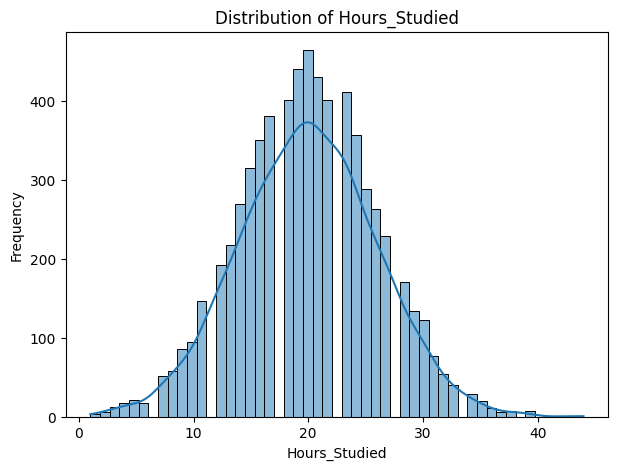

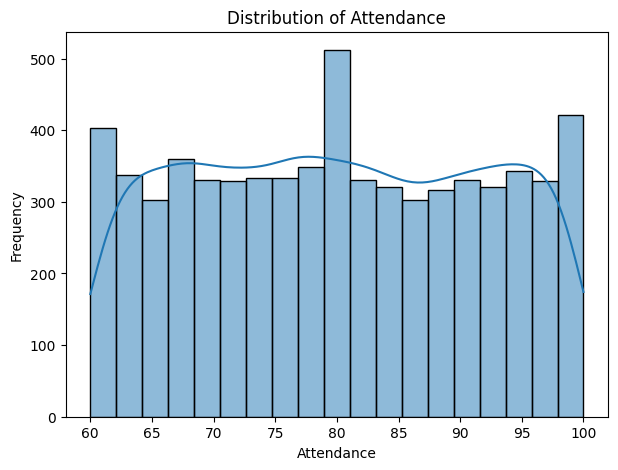

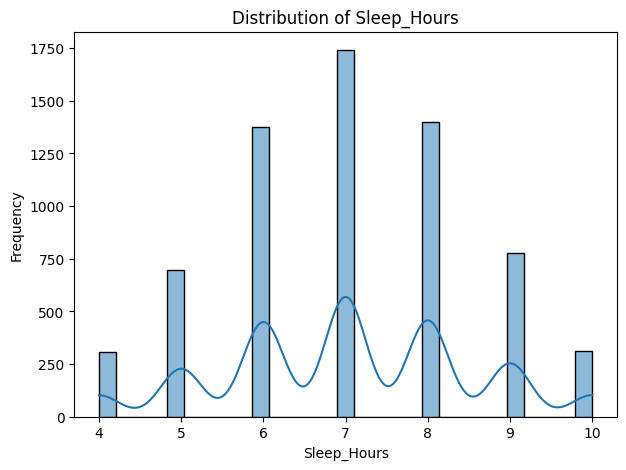

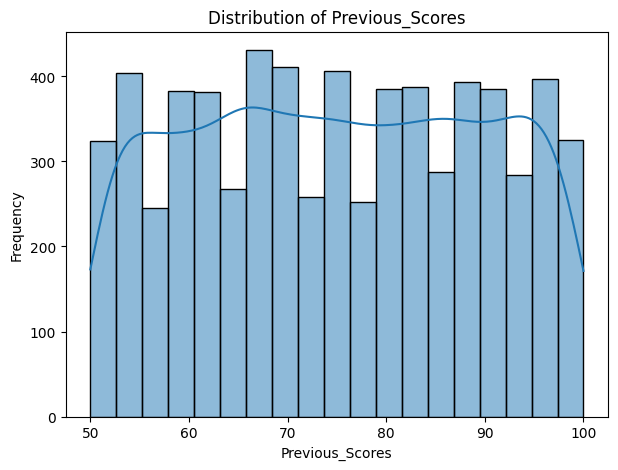

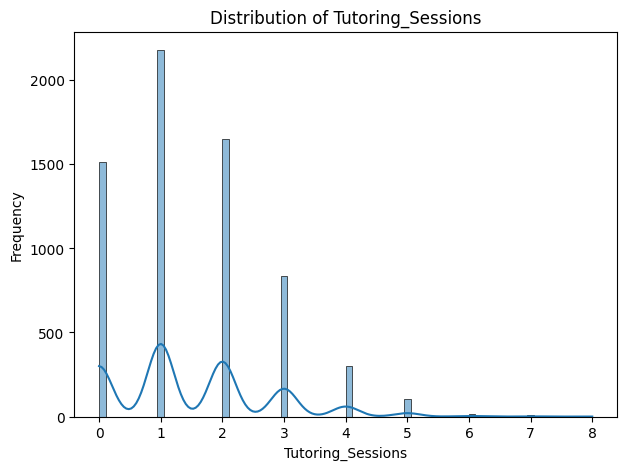

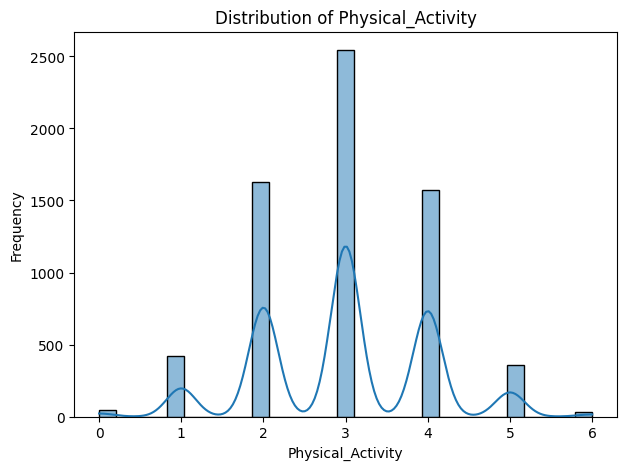

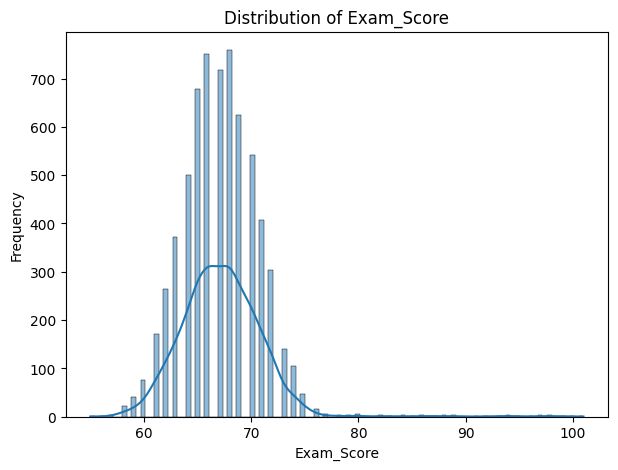

In [9]:
# check the distribution of the numerical columns
for col in num_col:
    plot_distribution(col)

**Count Plot of Categorical Columns**

C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


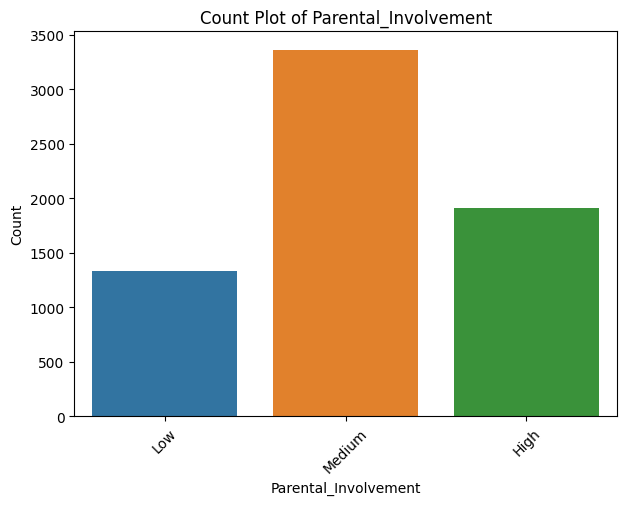

C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64


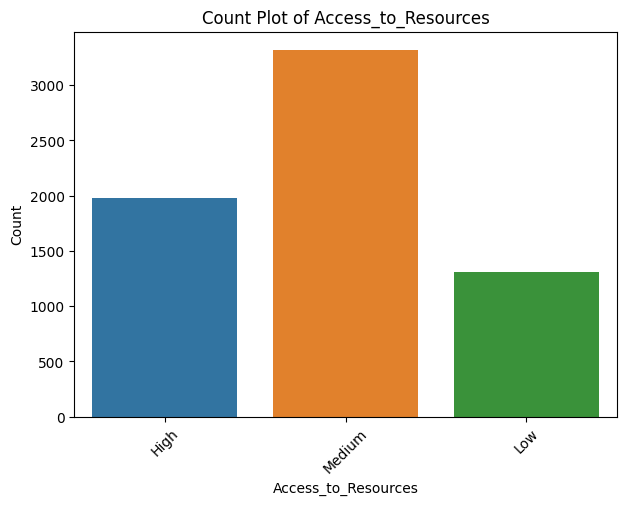

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


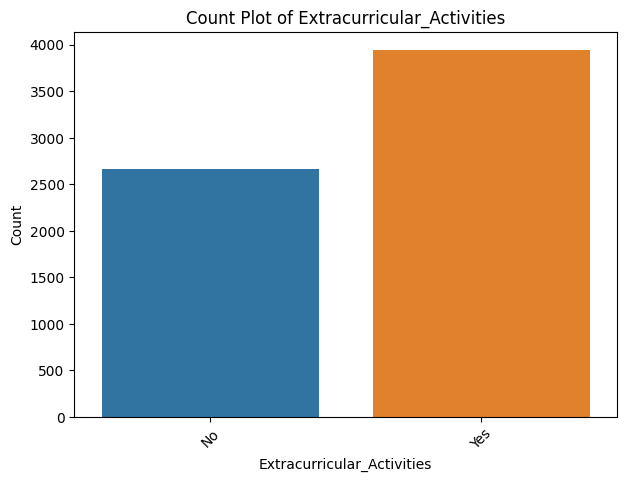

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


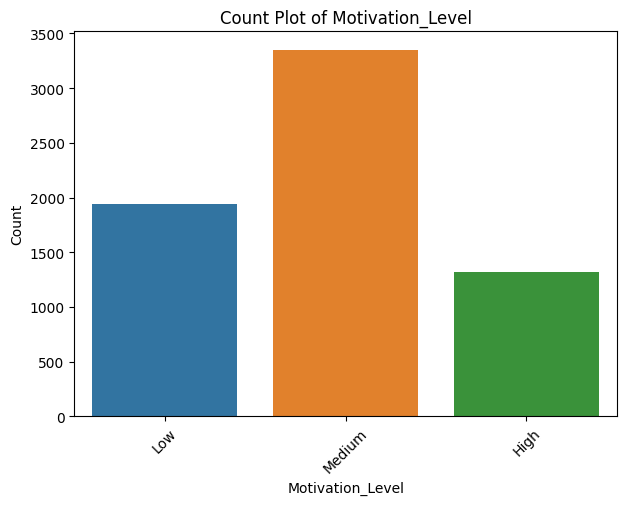

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


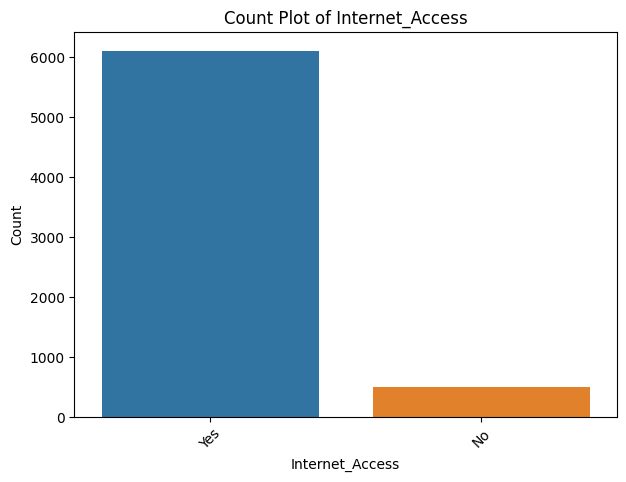

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


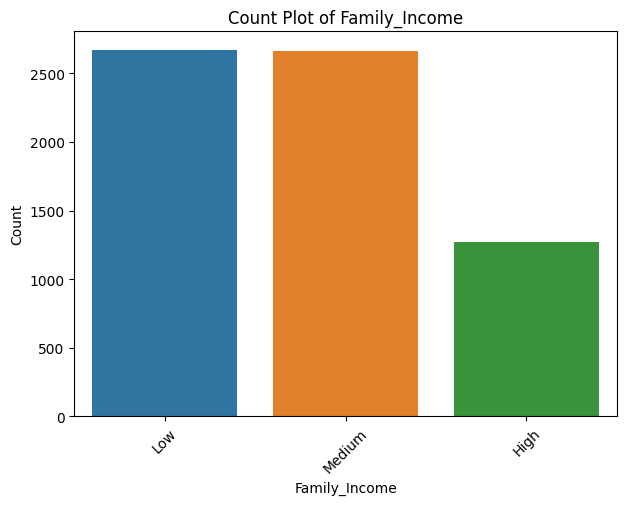

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


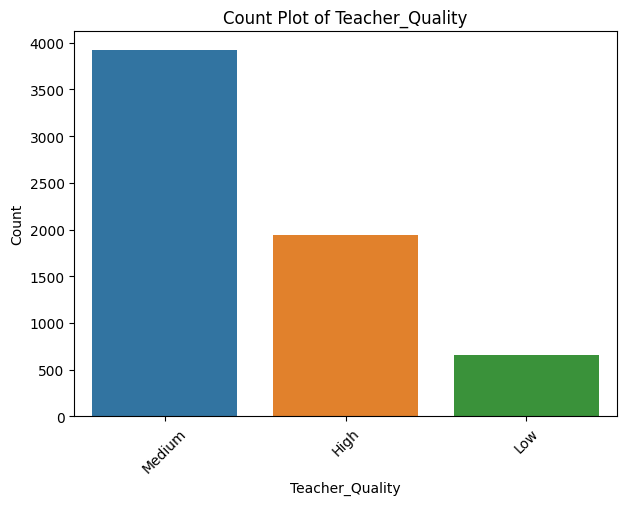

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


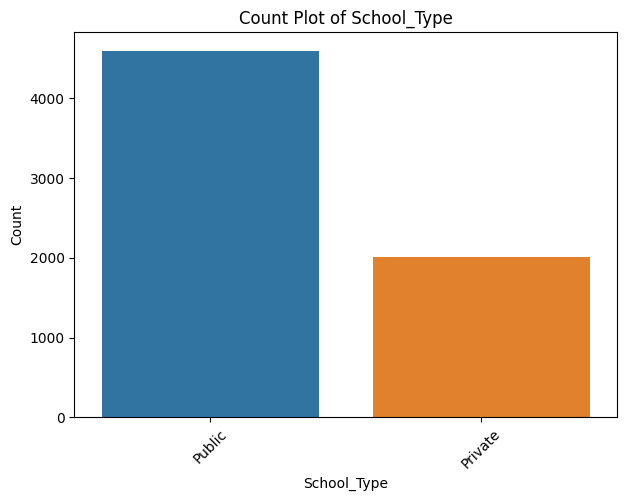

School_Type
Public     4598
Private    2009
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


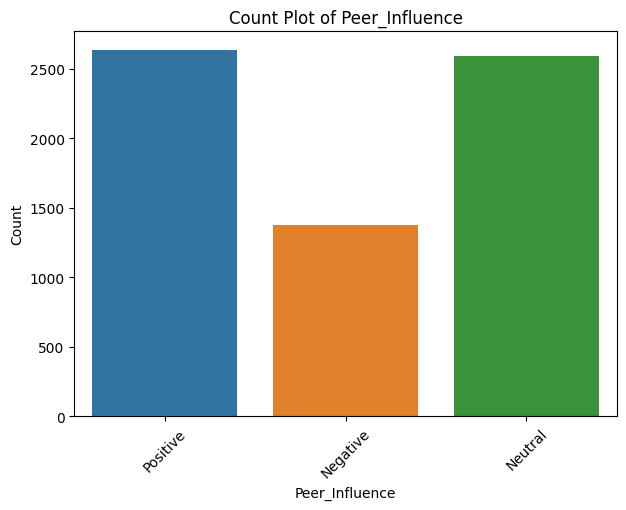

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


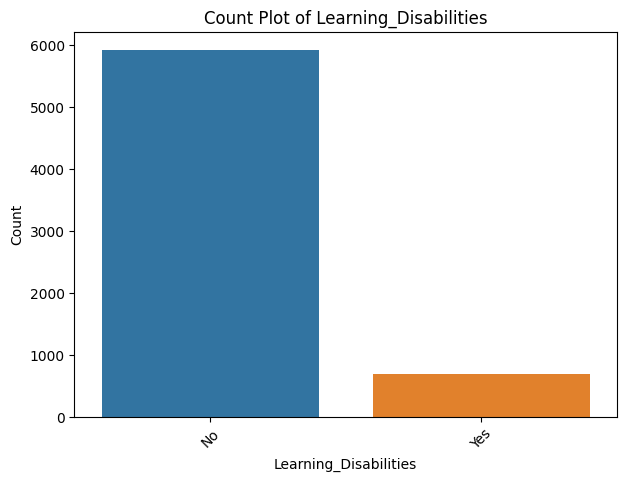

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


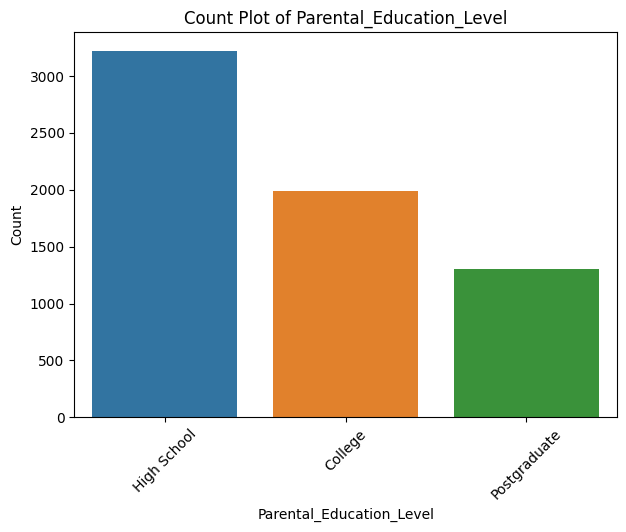

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


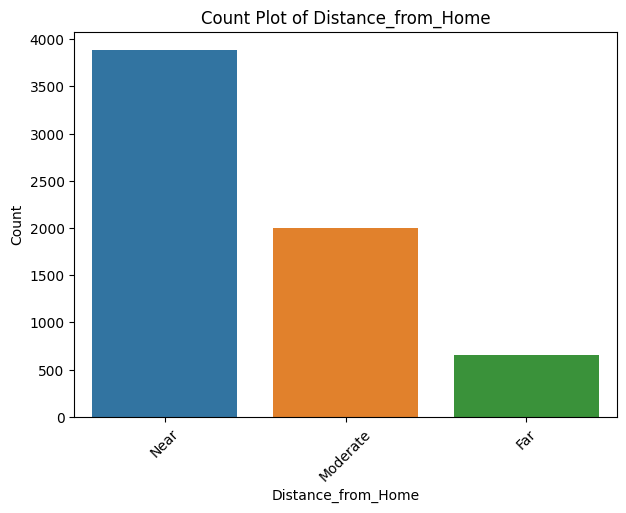

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64


C:\Users\Arif\AppData\Local\Temp\ipykernel_13016\308032610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='tab10')


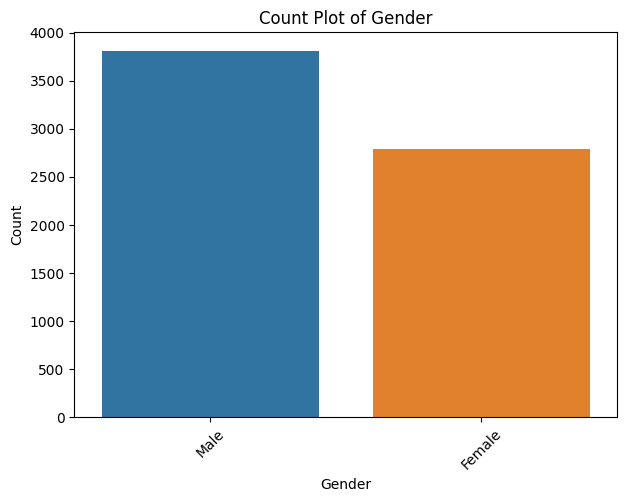

Gender
Male      3814
Female    2793
Name: count, dtype: int64


In [10]:
# check the count plot for categorical columns and add value counts to the plot
for col in cat_col:
    count_plot(col)
    print(df[col].value_counts())

**Feature vs target (exam_score)**

Text(0, 0.5, 'Exam Score')

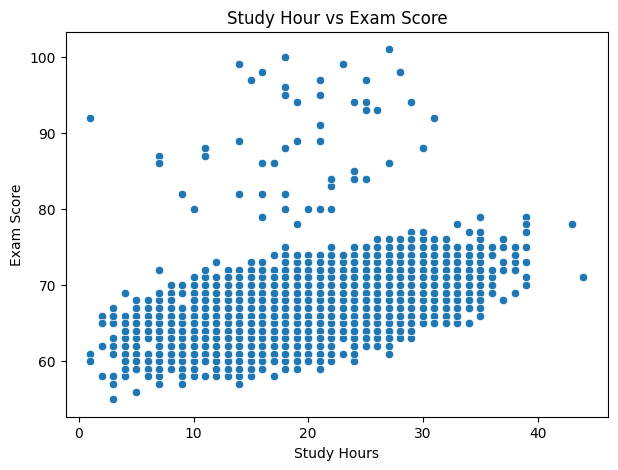

In [11]:
# show hourly study time vs final grade
plt.figure(figsize=(7, 5))  
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)
plt.title('Study Hour vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

There is a clear positive trend. Students who study more than 25 hours tend to get scores above 70.

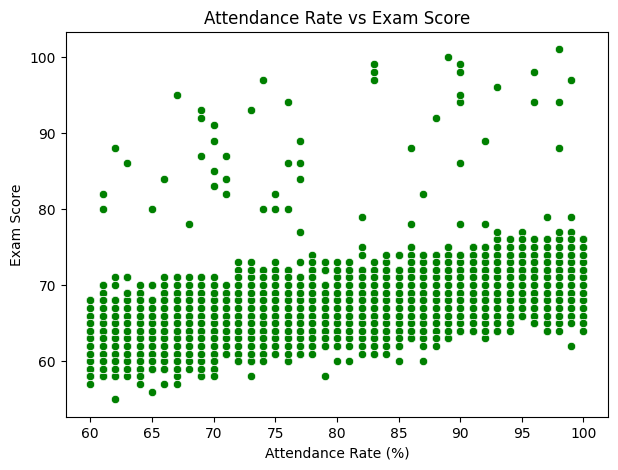

In [12]:
# show attendance vs final grade
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Attendance', y='Exam_Score', data=df, color='GREEN')
plt.title('Attendance Rate vs Exam Score')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Exam Score')
plt.show()

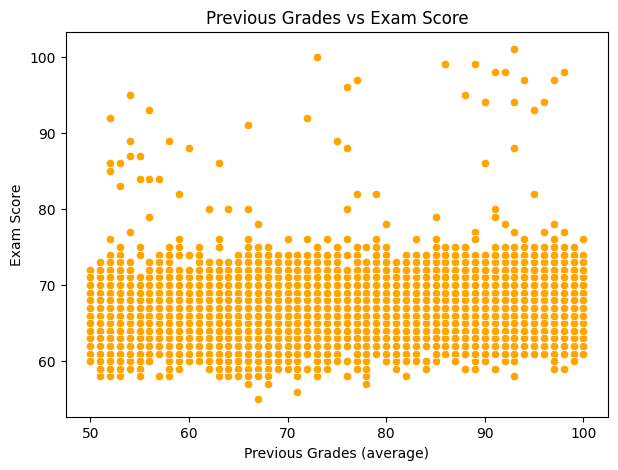

In [13]:
# show previous grades vs final grade
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Previous_Scores', y='Exam_Score', data=df, color='ORANGE')
plt.title('Previous Grades vs Exam Score')
plt.xlabel('Previous Grades (average)')
plt.ylabel('Exam Score')
plt.show()

In [14]:
# make function to check the box plot for numerical columns
def box_plot(column):
    plt.figure(figsize=(9, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

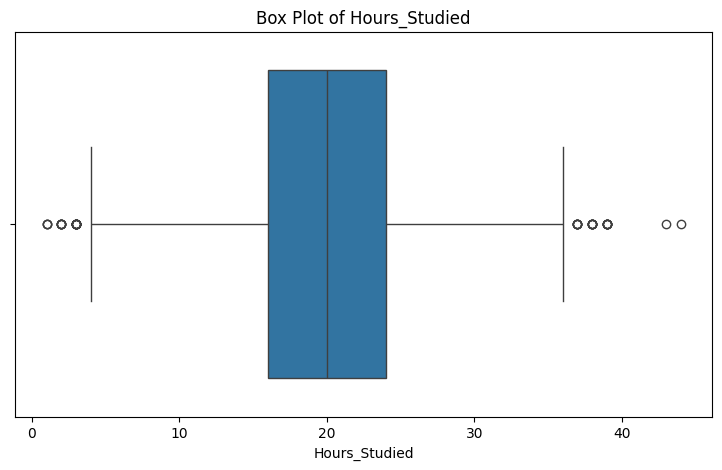

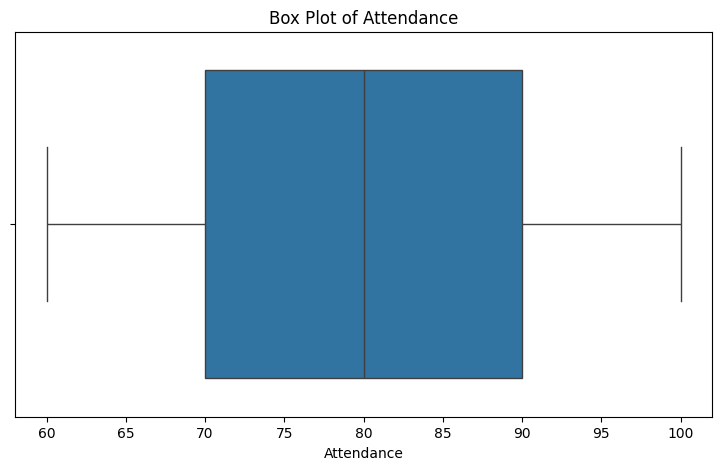

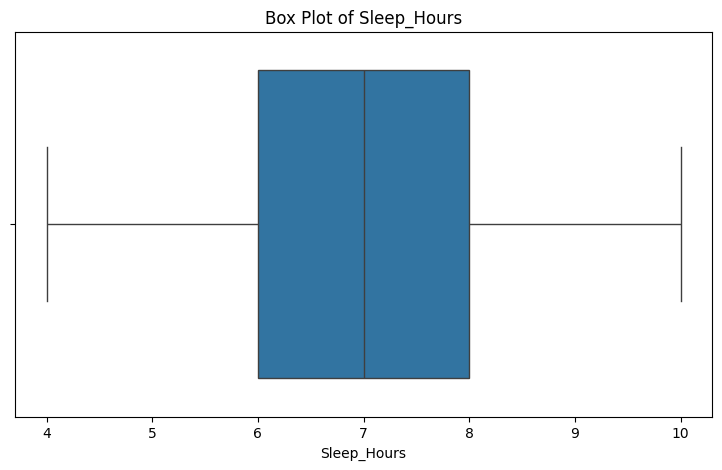

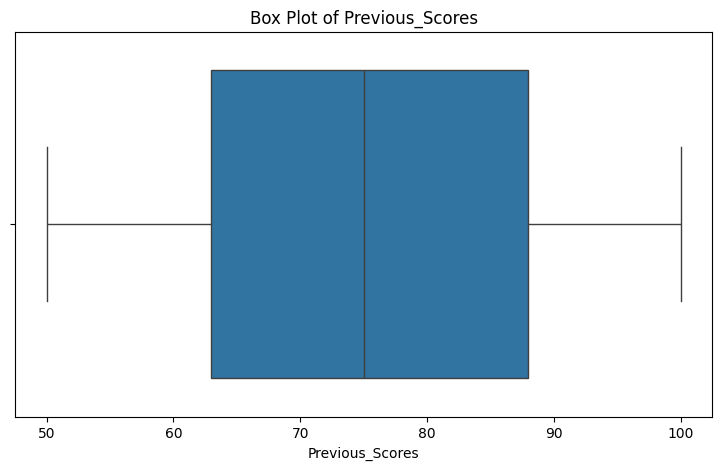

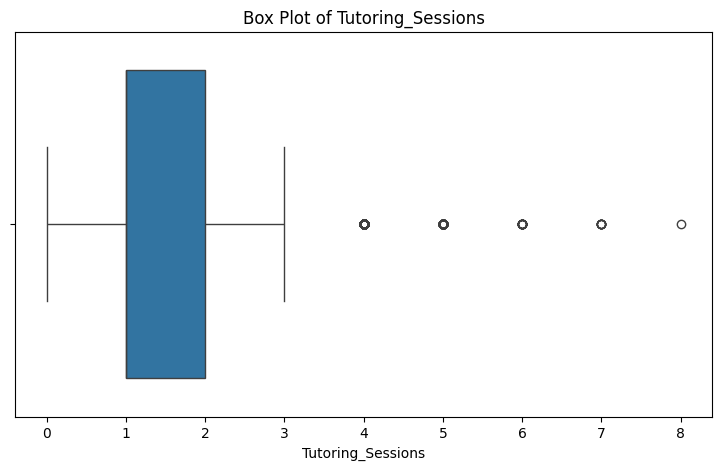

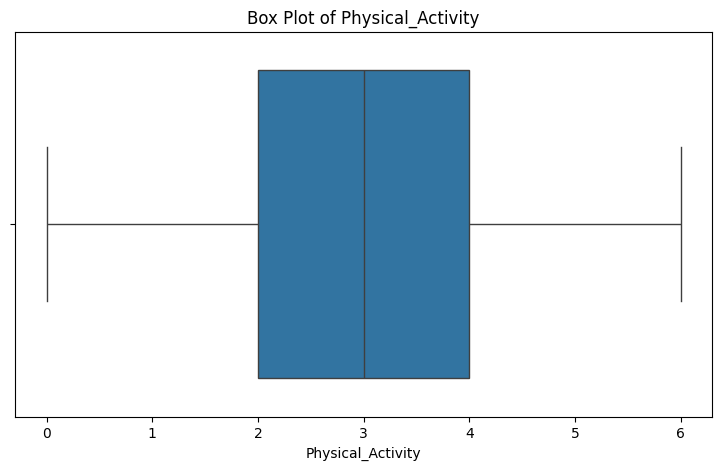

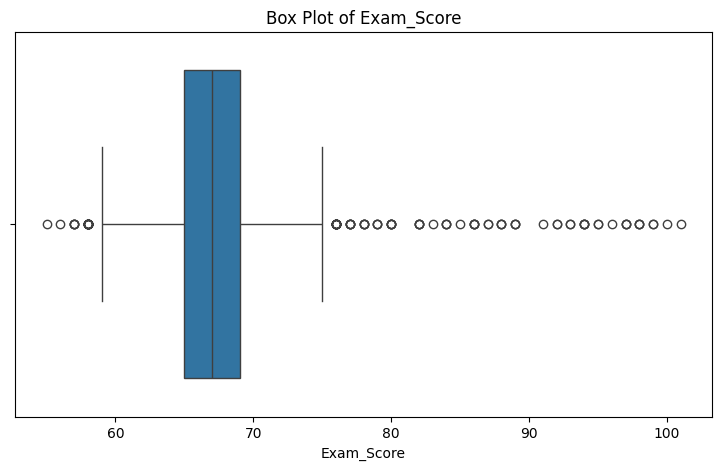

In [15]:
# check the box plot for numerical columns
for col in num_col:
    box_plot(col)

# **Correlation check**

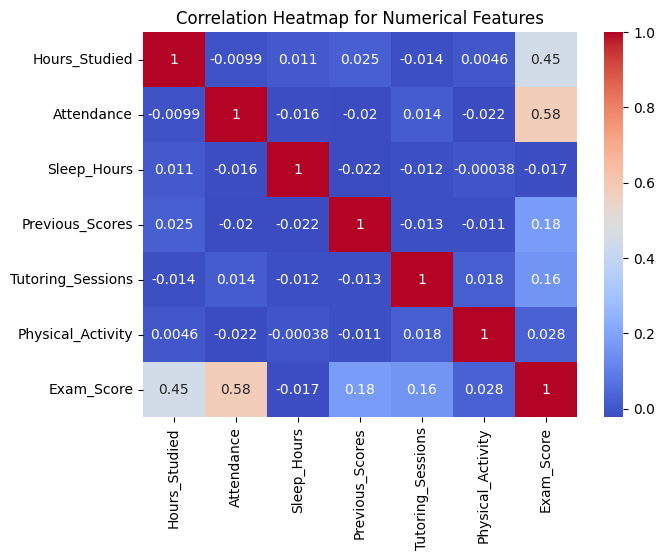

In [16]:
# chech correlation with heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

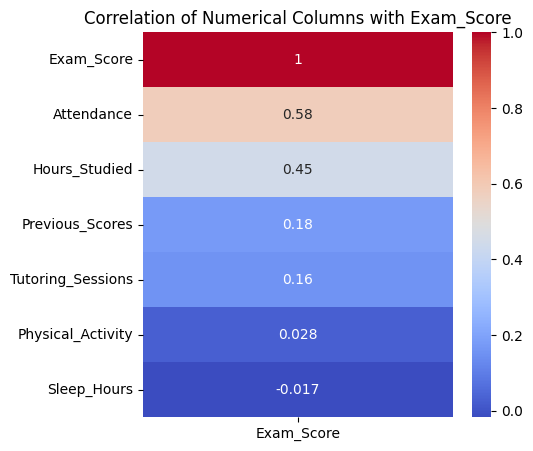

In [17]:
# correlation check numerical columns with target variable 'Exam_Score'
plt.figure(figsize=(5,5))
sns.heatmap(df[num_col].corr()['Exam_Score'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Columns with Exam_Score')
plt.show()

Attendance and Hours_Studied have a strong correlation with Exam_Score. Previous_Scores and Distance_from_Home have a weak correlation with Exam_Score.

# **Train Test Split**

In [18]:
# define featrures and target variable
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# train test split 
from sklearn.model_selection import train_test_split

# split the data into training and testing sets with 80% for training and 20% for testing, and set random_state to 42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, 
    test_size=0.20, 
    random_state=42
)

# **Split categorical and numerical columns**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [20]:
# split nominal and ordinal columns
numeric_col = [
    'Hours_Studied', 
    'Attendance', 
    'Sleep_Hours', 
    'Previous_Scores',
    'Tutoring_Sessions', 
    'Physical_Activity']

ordinal_col = [
    'Parental_Involvement', 
    'Access_to_Resources', 
    'Motivation_Level', 
    'Family_Income', 
    'Teacher_Quality', 
    'Peer_Influence',
    'Parental_Education_Level', 
    'Distance_from_Home']

nominal_col = [
    'Gender',
    'Internet_Access',
    'Extracurricular_Activities',
    'Learning_Disabilities',
    'School_Type']

In [21]:
ordinal_categories = [
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Negative', 'Neutral', 'Positive'],
    ['High School', 'College', 'Postgraduate'],
    ['Near', 'Moderate', 'Far']
]

# **Cleaning and preprocessing**

In [22]:
# import libaray for data preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories))
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [24]:
preprocessing = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_col),
    ('ord', ordinal_transformer, ordinal_col),
    ('nom', nominal_transformer, nominal_col)
])

# **Build Machine Learning Model (Without scaling)**

**1. Linear Regression**

In [25]:
# train with linear regression
from sklearn.linear_model import LinearRegression

# create a pipeline for linear regression
pipeline_linreg = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', LinearRegression())
])

# train the model with the training data
pipeline_linreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [26]:
# predict the test set
y_pred_linreg = pipeline_linreg.predict(X_test)

In [27]:
# evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_linreg)
mse = mean_squared_error(y_test, y_pred_linreg)
mape = mean_absolute_percentage_error(y_test, y_pred_linreg)*100
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linreg)

print(f'Mean Absolute Error: {mae:.2f}') 
print(f'Mean Squared Error: {mse:.2f}')
print(f'Mean Absolute Percetage Error: {mape:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Absolute Error: 0.44
Mean Squared Error: 3.24
Mean Absolute Percetage Error: 0.62
Root Mean Squared Error: 1.80
R-squared Score: 0.77


Result for linear regression is, linear regression can explain around **77%** variance of the target variable. The MAE value of 0.44 indicates that the average prediction error of the model is only about 0.44 test score points, which is relatively small. The RMSE value of 1.80 also indicates that the deviation of the prediction from the actual value is relatively low.  

**2. Decission Tree**

In [28]:
# import the decision tree regressor
from sklearn.tree import DecisionTreeRegressor

# create a pipeline for decision tree regressor
pipeline_dt = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', DecisionTreeRegressor(random_state=42))
])

# train the model
pipeline_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [29]:
# predict the test set
y_pred_dt = pipeline_dt.predict(X_test)

In [30]:
# evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt) * 100
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)


print(f'Mean Absolute Error: {mae_dt:.2f}')
print(f'Mean Squared Error: {mse_dt:.2f}')
print(f'Mean Absolute Percentage Error: {mape_dt:.2f}%')
print(f'Root Mean Squared Error: {rmse_dt:.2f}')
print(f'R-squared Score: {r2_dt:.2f}')

Mean Absolute Error: 1.64
Mean Squared Error: 10.03
Mean Absolute Percentage Error: 2.39%
Root Mean Squared Error: 3.17
R-squared Score: 0.29


In [31]:
# check overfitting by calculating the R-squared score on the training set
r2_train_dt = r2_score(y_train, pipeline_dt.predict(X_train))
r2_train_dt

1.0

**3. Random Forest**

In [32]:
# import the random forest regressor
from sklearn.ensemble import RandomForestRegressor

# create pipeline for random forest regressor
pipeline_rf = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(random_state=42))
])

# train the model 
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [33]:
# predict the test set
y_pred_rf = pipeline_rf.predict(X_test)

In [34]:
# evaluate the model

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)*100
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Absolute Error: {mae_rf:.2f}')
print(f'Mean Squared Error: {mse_rf:.2f}')
print(f'Mean Absolute Percentage Error: {mape_rf:.2f}%')
print(f'Root Mean Squared Error: {rmse_rf:.2f}')
print(f'R-squared Score: {r2_rf:.2f}')

Mean Absolute Error: 1.08
Mean Squared Error: 4.64
Mean Absolute Percentage Error: 1.56%
Root Mean Squared Error: 2.15
R-squared Score: 0.67


**4. Xgboost Regressor**

In [35]:
# import xgboost regressor
from xgboost import XGBRegressor

# create pipeline for xgboost regressor 
pipeline_xgb = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', XGBRegressor(random_state=42))
])

# train the model
pipeline_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [36]:
# predict the test set
y_pred_xgb = pipeline_xgb.predict(X_test)

In [37]:
# evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)*100
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)


print(f'Mean Absolute Error: {mae_xgb:.2f}')
print(f'Mean Squared Error: {mse_xgb:.2f}')
print(f'Mean Absolute Percentage Error: {mape_xgb:.2f}%')
print(f'Root Mean Squared Error: {rmse_xgb:.2f}')
print(f'R² Score: {r2_xgb:.2f}')

Mean Absolute Error: 0.98
Mean Squared Error: 4.96
Mean Absolute Percentage Error: 1.42%
Root Mean Squared Error: 2.23
R² Score: 0.65


# **Build Machine learning model (with scaling)**

**1. Ridge Regression**

In [38]:
# import ridge regression
from sklearn.linear_model import Ridge

# create a pipeline for ridge regression
pipeline_ridge = Pipeline([
    ("preprocessing", preprocessing),
    ("model", Ridge(alpha=1.0))
])

# train the model with the training data
pipeline_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [39]:
# predict the test set
y_pred_ridge = pipeline_ridge.predict(X_test)

In [40]:
# evaluate the model

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)*100
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)


print(f'Mean Absolute Error: {mae_ridge:.2f}')
print(f'Mean Squared Error: {mse_ridge:.2f}')
print(f'Mean Absolute Percentage Error: {mape_ridge:.2f}%')
print(f'Root Mean Squared Error: {rmse_ridge:.2f}')
print(f'R² Score: {r2_ridge:.2f}')

Mean Absolute Error: 0.44
Mean Squared Error: 3.24
Mean Absolute Percentage Error: 0.62%
Root Mean Squared Error: 1.80
R² Score: 0.77


**2. Lasso Regression**

In [41]:
# import library for lasso regression
from sklearn.linear_model import Lasso

# create a pipeline for lasso regression
pipeline_lasso = Pipeline([
    ("preprocessing", preprocessing),
    ("model", Lasso(alpha=1.0))
])

# train the model with the training data
pipeline_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [42]:
# predict the test set
y_pred_lasso = pipeline_lasso.predict(X_test)

In [43]:
# evaluate the model

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)*100
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f'Mean Absolute Error: {mae_lasso:.2f}')
print(f'Mean Squared Error: {mse_lasso:.2f}')
print(f'Mean Absolute Percentage Error: {mape_lasso:.2f}%')
print(f'Root Mean Squared Error: {rmse_lasso:.2f}')
print(f'R² Score: {r2_lasso:.2f}')

Mean Absolute Error: 1.91
Mean Squared Error: 7.95
Mean Absolute Percentage Error: 2.81%
Root Mean Squared Error: 2.82
R² Score: 0.44


**Support Vector Regression**

In [44]:
# import library for support vector regression
from sklearn.svm import SVR

# create support vector regression model with radial basis function kernel
pipeline_svr = Pipeline([
    ("preprocessing", preprocessing),
    ("model", SVR(kernel="rbf"))
])

# train the model
pipeline_svr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [45]:
# predict the test set
y_pred_svr = pipeline_svr.predict(X_test)

In [46]:
# evaluate the model

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mape_svr = mean_absolute_percentage_error(y_test, y_pred_svr) * 100
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f'Mean Absolute Error: {mae_svr:.2f}')
print(f'Mean Squared Error: {mse_svr:.2f}')
print(f'Mean Absolute Percentage Error: {mape_svr:.2f}%')
print(f'Root Mean Squared Error: {rmse_svr:.2f}')
print(f'R² Score: {r2_svr:.2f}')


Mean Absolute Error: 0.51
Mean Squared Error: 3.35
Mean Absolute Percentage Error: 0.71%
Root Mean Squared Error: 1.83
R² Score: 0.76


# **Cross Validation**

In [47]:
# imort cross validation
from sklearn.model_selection import cross_val_score

**Linear Regression**

In [48]:
# cross validation for linear regression
cv_scores_lr = cross_val_score(pipeline_linreg, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores_lr)
print(f'Average Cross-validation R2 score: {cv_scores_lr.mean():.2f}')

Cross-validation R2 scores: [0.6257275  0.72357365 0.70944613 0.73358481 0.84037137]
Average Cross-validation R2 score: 0.73


**Decision Tree**

In [49]:
# cross validation for decision tree 
cv_scores_dt = cross_val_score(pipeline_dt, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores_dt)
print(f'Average Cross-validation R2 score: {cv_scores_dt.mean():.2f}')

Cross-validation R2 scores: [0.20947647 0.19967947 0.24991333 0.30650433 0.23364363]
Average Cross-validation R2 score: 0.24


**Random Forest**

In [50]:
# cross validation for random forest regressor
cv_scores_rf = cross_val_score(pipeline_rf, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores_rf)
print(f'Average Cross-validation R2 score: {cv_scores_rf.mean():.2f}')

Cross-validation R2 scores: [0.54867605 0.6477372  0.61992059 0.65778057 0.72908711]
Average Cross-validation R2 score: 0.64


**Xgboost Regressor**

In [51]:
cv_scores_xgb = cross_val_score(pipeline_xgb, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores_xgb)
print(f'Average Cross-validation R2 score: {cv_scores_xgb.mean():.2f}')

Cross-validation R2 scores: [0.5527994  0.66701508 0.61855185 0.65003502 0.73093081]
Average Cross-validation R2 score: 0.64


**Ridge Regression**

In [52]:
cv_score_ridge = cross_val_score(pipeline_ridge, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_score_ridge)
print(f'Average Cross-validation R2 score: {cv_score_ridge.mean():.2f}')

Cross-validation R2 scores: [0.62573966 0.72357563 0.70945721 0.73358297 0.84035247]
Average Cross-validation R2 score: 0.73


**Lasso Regression**

In [53]:
cv_score_lasso = cross_val_score(pipeline_lasso, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_score_lasso)
print(f'Average Cross-validation R2 score: {cv_score_lasso.mean():.2f}')

Cross-validation R2 scores: [0.35805634 0.40361086 0.41385394 0.40713489 0.45465486]
Average Cross-validation R2 score: 0.41


**Support Vector Regression**

In [54]:
cv_score_svr = cross_val_score(pipeline_svr, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_score_svr)
print(f'Average Cross-validation R2 score: {cv_score_svr.mean():.2f}')

Cross-validation R2 scores: [0.6178601  0.70987605 0.70120391 0.72757754 0.82718346]
Average Cross-validation R2 score: 0.72


# **Tunning the best model**

because Linear and Ridge regression is the best model so i want to tunning it

In [55]:
# import library grid search cv
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

In [56]:
# create ridge regression model
ridge = Ridge()

pipeline_ridge = Pipeline([
    ("preprocessing", preprocessing),
    ("model", ridge)
])

# set parameter grid for alpha
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# create grid search cv
grid = GridSearchCV(
    pipeline_ridge,
    param_grid,
    cv=5,
    scoring='r2'
)

# train the model with grid search cv
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

**Best model is Ridge Regression with alpha = 10**

In [57]:
# Show best alpha
print(grid.best_params_)

# show the best score
print(grid.best_score_)

{'model__alpha': 10}
0.7236712421144483


In [58]:
# best model
best_model = grid.best_estimator_

In [59]:
# predict the test set with best model
y_pred_best_model = best_model.predict(X_test)

In [60]:
# Evaluate the model after tuning

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_grid = mean_absolute_error(y_test, y_pred_best_model)
mse_grid= mean_squared_error(y_test, y_pred_best_model)
mape_grid = mean_absolute_percentage_error(y_test, y_pred_best_model)*100
rmse_grid= np.sqrt(mse_grid)
r2_grid= r2_score(y_test, y_pred_best_model)

print(f'Mean Absolute Error: {mae_grid:.2f}')
print(f'Mean Squared Error: {mse_grid:.2f}')
print(f'Mean Absolute Percentage Error: {mape_grid:.2f}%')
print(f'Root Mean Squared Error: {rmse_grid:.2f}')
print(f'R² Score: {r2_grid:.2f}')


Mean Absolute Error: 0.44
Mean Squared Error: 3.24
Mean Absolute Percentage Error: 0.62%
Root Mean Squared Error: 1.80
R² Score: 0.77


# **Recommendation**

# **Save the model**

In [61]:
# import library
import joblib

# save the best model to a file
joblib.dump(best_model, 'model_exam_prediction.pkl')

['model_exam_prediction.pkl']